<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/51_learning_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Curves

In this notebook, we use learning curves to analyze model performance as the training dataset size increases and identify underfitting or overfitting behavior.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import learning_curve

In [4]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [5]:
model = DecisionTreeClassifier(
    random_state=42
)

In [6]:
train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    )
)

In [7]:
train_mean = train_scores.mean(
    axis=1
)

validation_mean = validation_scores.mean(
    axis=1
)

In [8]:
results_df = pd.DataFrame({
    "Training Size":
        train_sizes,

    "Training Accuracy":
        train_mean,

    "Validation Accuracy":
        validation_mean
})

results_df

,Training Size,Training Accuracy,Validation Accuracy
0,80,1.0,0.781
1,160,1.0,0.810
2,240,1.0,0.865
3,320,1.0,0.871
4,400,1.0,0.868
5,480,1.0,0.886
6,560,1.0,0.882
7,640,1.0,0.894
8,720,1.0,0.883
9,800,1.0,0.896


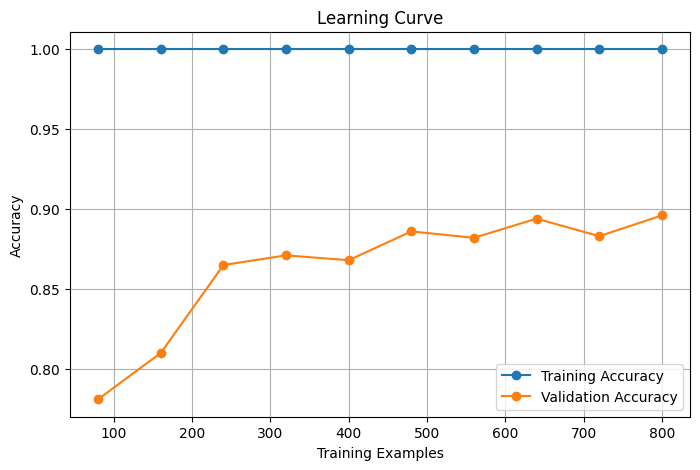

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel(
    "Training Examples"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Learning Curve"
)

plt.legend()

plt.grid()

plt.show()

In [10]:
results_df["Gap"] = (
    results_df["Training Accuracy"]
    -
    results_df["Validation Accuracy"]
)

results_df

,Training Size,Training Accuracy,Validation Accuracy,Gap
0,80,1.0,0.781,0.219
1,160,1.0,0.810,0.190
2,240,1.0,0.865,0.135
3,320,1.0,0.871,0.129
4,400,1.0,0.868,0.132
5,480,1.0,0.886,0.114
6,560,1.0,0.882,0.118
7,640,1.0,0.894,0.106
8,720,1.0,0.883,0.117
9,800,1.0,0.896,0.104


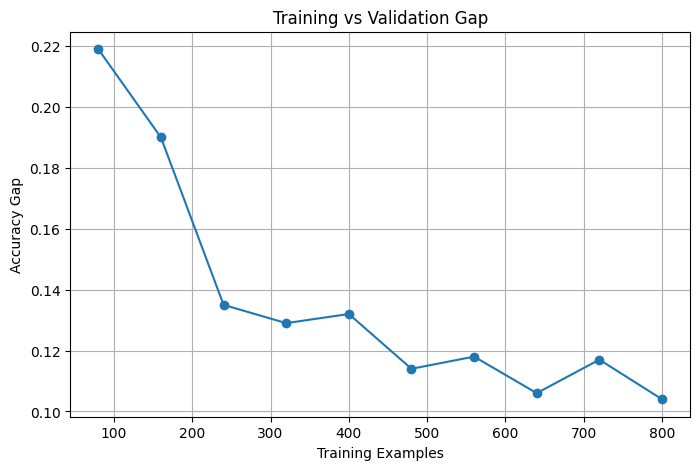

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    results_df["Gap"],
    marker='o'
)

plt.xlabel(
    "Training Examples"
)

plt.ylabel(
    "Accuracy Gap"
)

plt.title(
    "Training vs Validation Gap"
)

plt.grid()

plt.show()

In [12]:
final_gap = results_df["Gap"].iloc[-1]

if final_gap > 0.10:
    print("Possible Overfitting")

elif final_gap < 0.03:
    print("Good Generalization")

else:
    print("Moderate Generalization")

Possible Overfitting


## Conclusion

Learning Curves were used to analyze model performance as training data increased.

Observations:
- Training accuracy generally decreases as more data is added.
- Validation accuracy generally improves with more data.
- The gap between training and validation performance indicates possible overfitting.
- Learning Curves help understand model generalization behavior.